# Ramp-Metering Strategy Analysis

A self-contained KPI analysis comparing **all 12 control strategies** across six headline metrics, with a configurable **focus-strategy deep dive**.

**Sections**
1. Setup & Configuration
2. Helpers & Data Loading
3. KPI Dashboard — All Strategies
4. Composite Score & Radar
5. Pairwise Improvement Matrix
6. Demand-Conditioned KPI Heatmaps
7. Focus Strategy Deep Dive
8. Robustness & Trade-offs

## 1. Setup & Configuration

In [40]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

BENCHMARKS_DIR = (Path(".") / "../benchmarks").resolve()
PLOTS_DIR = Path("plots") / "analysis"

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="deep",
    font_scale=1.15,
    rc={
        "figure.figsize": (12, 7),
        "grid.linestyle": "--",
        "grid.color": "0.85",
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

### Configuration

`FOCUS_STRATEGY` is the single knob driving Section 7's deep dive — change it and re-run the focus section to compare any strategy against the others.

`HIGHER_IS_BETTER` lists the metrics where larger values are better (only mainline merge speed). Every ranking and improvement calculation respects this direction.

In [41]:
# (display name, csv filename, color)
STRATEGY_CATALOG: list[tuple[str, str, str]] = [
    # ("DQN Hybrid (Partial Obs.)",        "results_DQNAgentHybridPartial.csv",    "#1f77b4"),
    # ("DQN Hybrid (Full Obs.)",           "results_DQNAgentHybridFull.csv",       "#ff7f0e"),
    # ("DQN Macro + Lane Obs.",            "results_DQNAgentMacroLane.csv",        "#2ca02c"),
    # ("DQN Macro (No Lane Obs.)",         "results_DQNAgentMacroNoLaneNew.csv",   "#d62728"),
    ("RM Only",                          "results_DQNAgentMacroLane.csv",   "#d62728"),
    # ("DQN Macro with PER (No Lane Obs.)","results_DQNAgentHybridPartialPer.csv", "#9467bd"),
    # ("DQN Hybrid (Full Obs.) - New",     "results_DQNAgentHybridFull_NEW.csv",   "#e377c2"),
    ("ALINEA",                           "results_AlineaDsBaseline.csv",         "#7f7f7f"),
    ("PI-ALINEA",                        "results_PiAlineaDsBaseline.csv",       "#bcbd22"),
    ("Fixed-Control",                    "results_FixedCycleBaseline.csv",       "#17becf"),
    ("No Control",                       "results_AlwaysGreenBaseline.csv",      "#aec7e8"),
    ("RM+LCC",              "results_DQNAgent_ramp_metering_lane_control_hybrid.csv",      "#a7c7e8"),
    ("RM+LCC Macro with SetMaxSpeed(5.0)","results_DQNAgent_lane_control_macro_only_new.csv","#a1c7e8"),
]

ALL_STRATEGIES   = [n for n, _, _ in STRATEGY_CATALOG]
STRATEGY_FILES   = {n: str(BENCHMARKS_DIR / f) for n, f, _ in STRATEGY_CATALOG}
STRATEGY_COLORS  = {n: c for n, _, c in STRATEGY_CATALOG}

METRICS = {
    "total_travel_time":                 "Total Time Spent (s)",
    "avg_time_loss":                     "Average Delay (s/veh)",
    "avg_ramp_queue_veh":                "Average Queue Length (veh)",
    "total_spillback_time_sec":          "Total Spillback (s)",
    "avg_mainline_speed_mergeArea_km/h": "Average Merge Speed (km/h)",
    "total_co2_mg":                      "Total CO2 Emissions (mg)",
}
HIGHER_IS_BETTER = {"avg_mainline_speed_mergeArea_km/h"}

MAINLINE_LEVELS = ["Low Mainline", "Medium Mainline", "High Mainline"]
RAMP_LEVELS     = ["Low On-Ramp",  "Medium On-Ramp",  "High On-Ramp"]

# === Change this to deep-dive any other strategy in Section 7 ===
FOCUS_STRATEGY = "RM+LCC Macro with SetMaxSpeed(5.0)"
FOCUS_COLOR    = "#111111"   # accent for focus strategy in head-to-head plots

## 2. Helpers & Data Loading

Load all 12 benchmark CSVs, tag rows with their strategy name, and bin every episode into one of 9 demand cells (3 mainline × 3 on-ramp).

In [42]:
def slugify(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[\s/]+", "_", text)
    return re.sub(r"[^\w-]", "", text)


def metric_sort_ascending(metric_key: str) -> bool:
    return metric_key not in HIGHER_IS_BETTER


def pct_improvement(focus_val: float, other_val: float, metric_key: str) -> float:
    """Positive = focus is better than other."""
    if other_val == 0:
        return np.nan
    if metric_key in HIGHER_IS_BETTER:
        return ((focus_val - other_val) / other_val) * 100
    return ((other_val - focus_val) / other_val) * 100


def normalize_metric(series: pd.Series, metric_key: str) -> pd.Series:
    """Min-max scale to [0, 1] where 1 = best, regardless of metric direction."""
    lo, hi = series.min(), series.max()
    if hi == lo:
        return pd.Series(np.ones_like(series, dtype=float), index=series.index)
    scaled = (series - lo) / (hi - lo)
    return scaled if metric_key in HIGHER_IS_BETTER else 1 - scaled


def save_fig(fig: plt.Figure, section: str, title: str, dpi: int = 200) -> Path:
    out = PLOTS_DIR / section
    out.mkdir(parents=True, exist_ok=True)
    path = out / f"{slugify(title)}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path


def load_benchmarks() -> pd.DataFrame:
    frames = []
    for strategy, filepath in STRATEGY_FILES.items():
        p = Path(filepath)
        if not p.is_file():
            print(f"Warning: missing '{p.name}' — skipping {strategy}.")
            continue
        df = pd.read_csv(p)
        df.columns = df.columns.str.strip()
        df["strategy"] = strategy
        frames.append(df)
    if not frames:
        raise RuntimeError("No benchmark CSVs were loaded.")
    return pd.concat(frames, ignore_index=True)


def categorize_demand(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["mainline_demand"] = pd.cut(
        df["main_flow_vph"], bins=[0, 4750, 5750, float("inf")],
        labels=MAINLINE_LEVELS, right=False,
    )
    df["on_ramp_demand"] = pd.cut(
        df["on_ramp_flow_vph"], bins=[0, 1600, 1800, float("inf")],
        labels=RAMP_LEVELS, right=False,
    )
    df["demand_cell"] = df["mainline_demand"].astype(str) + " / " + df["on_ramp_demand"].astype(str)
    return df

In [43]:
df = categorize_demand(load_benchmarks())
present_strategies = [s for s in ALL_STRATEGIES if s in df["strategy"].unique()]

print(f"Loaded {len(df):,} rows across {len(present_strategies)} strategies.\n")
roster = df.groupby("strategy", sort=False).size().rename("episodes").to_frame()
roster = roster.reindex(present_strategies)
display(roster.style.background_gradient(cmap="Blues"))

assert FOCUS_STRATEGY in present_strategies, (
    f"FOCUS_STRATEGY '{FOCUS_STRATEGY}' was not loaded — check STRATEGY_CATALOG."
)

Loaded 350 rows across 7 strategies.



,episodes
strategy,
RM Only,50
ALINEA,50
PI-ALINEA,50
Fixed-Control,50
No Control,50
RM+LCC,50
RM+LCC Macro with SetMaxSpeed(5.0),50


## 3. KPI Dashboard — All Strategies

A three-panel view of every strategy on every headline KPI:
- **Heatmap table** of mean KPI values, colour-graded per column (green = better)
- **Bar chart** per KPI, sorted best → worst, with the focus strategy outlined
- **Violin plot** per KPI, showing the per-episode distribution shape across all 50 episodes

In [44]:
strategy_means = (
    df.groupby("strategy", sort=False)[list(METRICS)].mean().reindex(present_strategies)
)
strategy_means_display = strategy_means.rename(columns=METRICS)

styled = strategy_means_display.style.format("{:,.2f}")
for metric_key, metric_name in METRICS.items():
    cmap = "RdYlGn" if metric_key in HIGHER_IS_BETTER else "RdYlGn_r"
    styled = styled.background_gradient(cmap=cmap, subset=[metric_name], axis=0)

display(Markdown("**Per-strategy mean of each KPI** (column-wise gradient — green is better)"))
display(styled)

**Per-strategy mean of each KPI** (column-wise gradient — green is better)

,Total Time Spent (s),Average Delay (s/veh),Average Queue Length (veh),Total Spillback (s),Average Merge Speed (km/h),Total CO2 Emissions (mg)
strategy,,,,,,
RM Only,"376,819.84",21.19,14.69,44.00,13.85,"1,783,849,367.18"
ALINEA,"417,836.80",27.53,14.18,381.30,13.41,"1,646,573,304.66"
PI-ALINEA,"426,418.10",29.10,14.28,625.28,13.48,"1,656,096,458.08"
Fixed-Control,"386,182.16",23.52,15.57,1.58,14.18,"1,576,992,817.73"
No Control,"576,047.16",57.21,10.06,1.40,12.62,"1,822,323,144.65"
RM+LCC,"372,863.74",19.72,14.33,179.20,13.78,"1,580,634,875.20"
RM+LCC Macro with SetMaxSpeed(5.0),"368,090.80",19.17,14.53,40.00,14.07,"1,569,923,554.33"


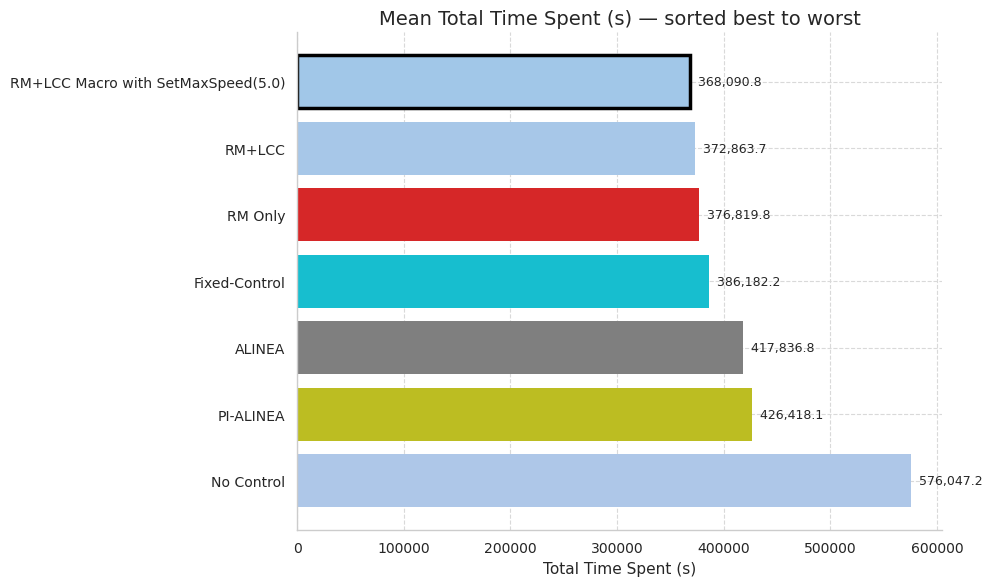

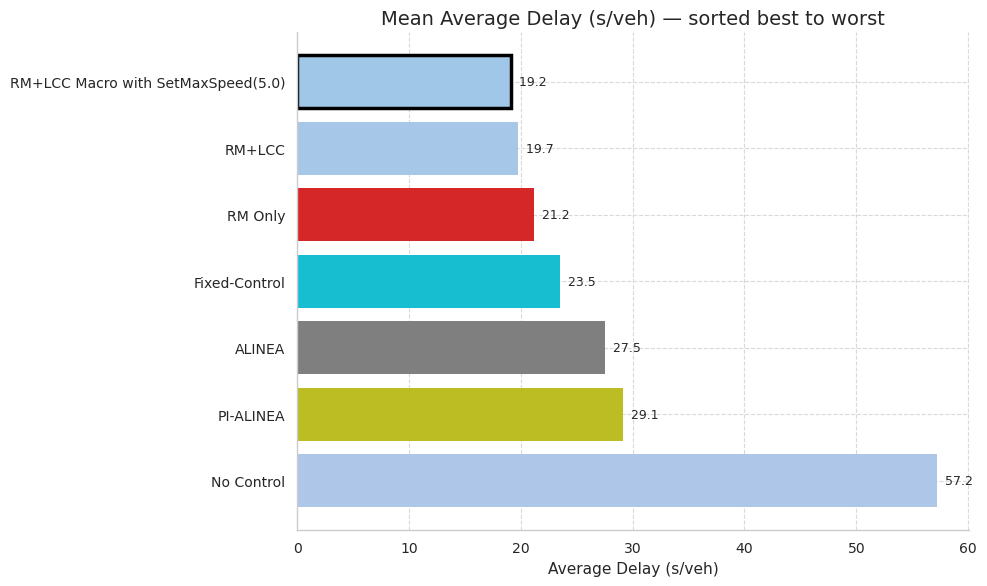

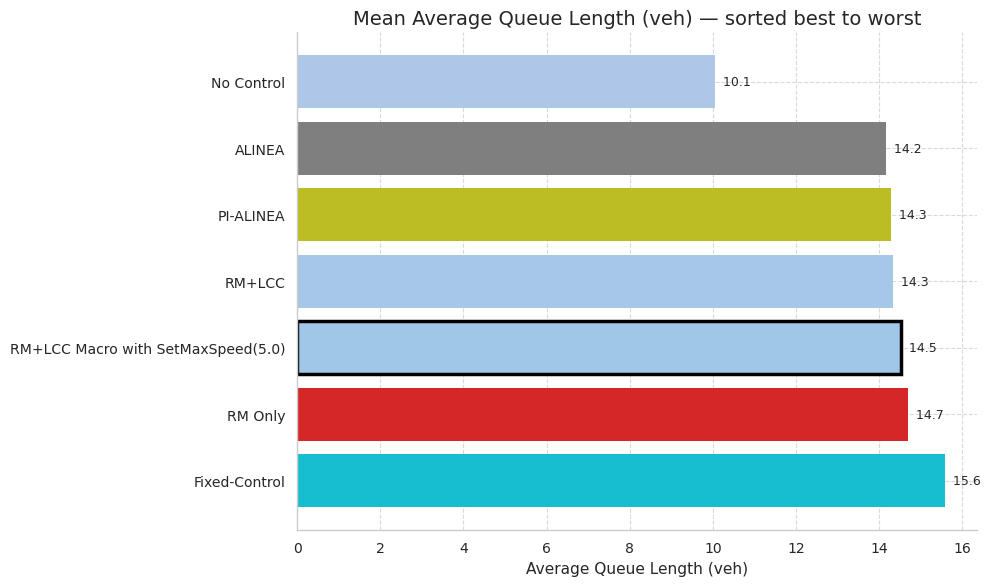

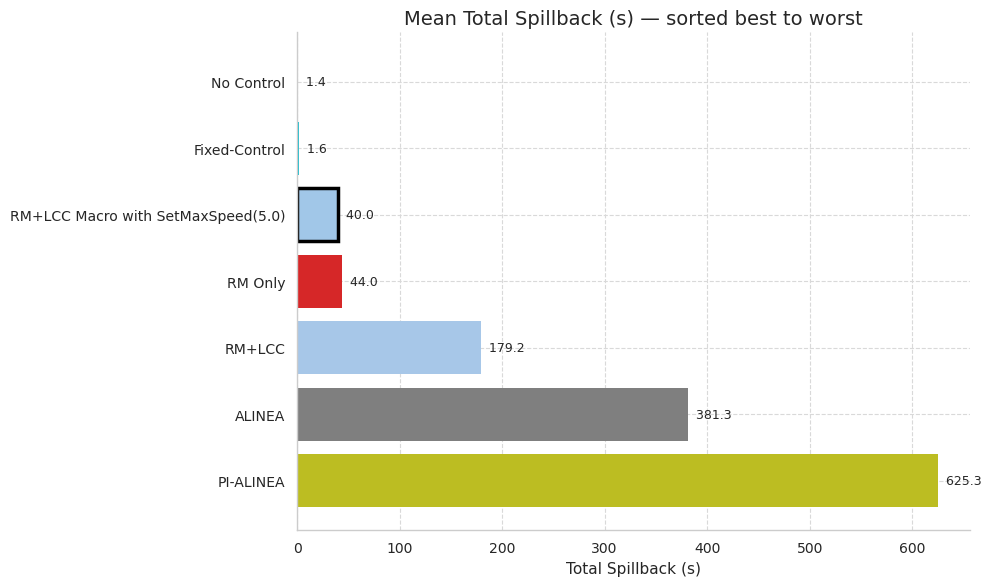

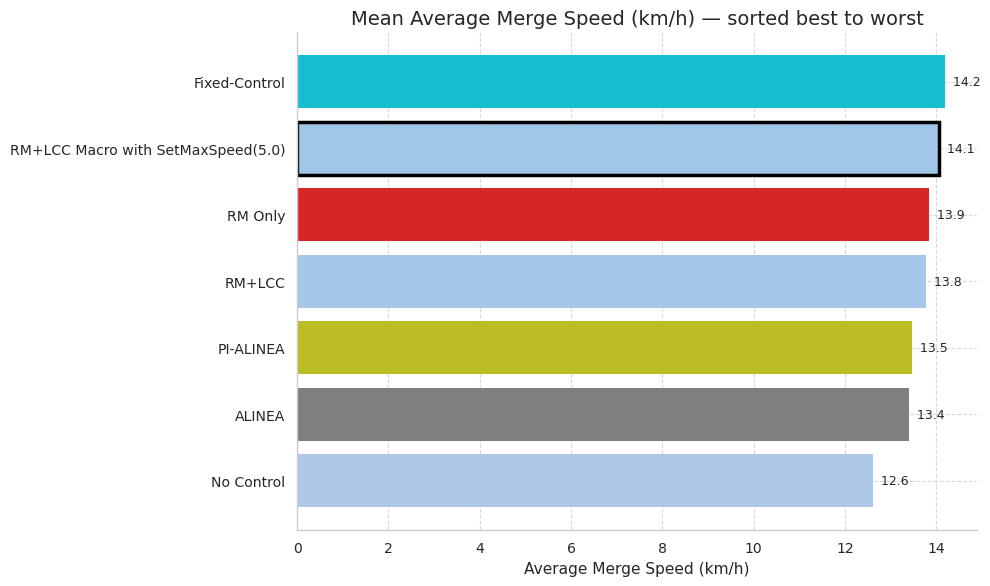

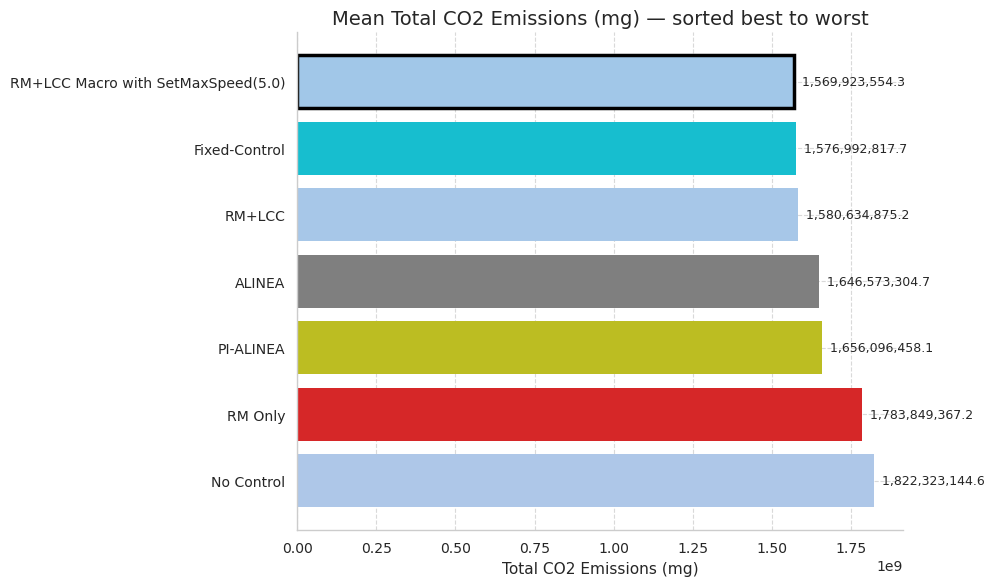

In [45]:
for metric_key, metric_name in METRICS.items():
    asc = metric_sort_ascending(metric_key)
    series = strategy_means[metric_key].sort_values(ascending=asc)
    colors = [STRATEGY_COLORS[s] for s in series.index]
    edges  = ["black" if s == FOCUS_STRATEGY else "none" for s in series.index]
    widths = [2.5     if s == FOCUS_STRATEGY else 0      for s in series.index]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(series.index, series.values, color=colors,
                   edgecolor=edges, linewidth=widths)
    title = f"Mean {metric_name} — sorted best to worst"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(metric_name)
    ax.invert_yaxis()
    for bar, val in zip(bars, series.values):
        ax.text(val, bar.get_y() + bar.get_height() / 2,
                f"  {val:,.1f}", va="center", fontsize=9)
    save_fig(fig, "kpi_dashboard", title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

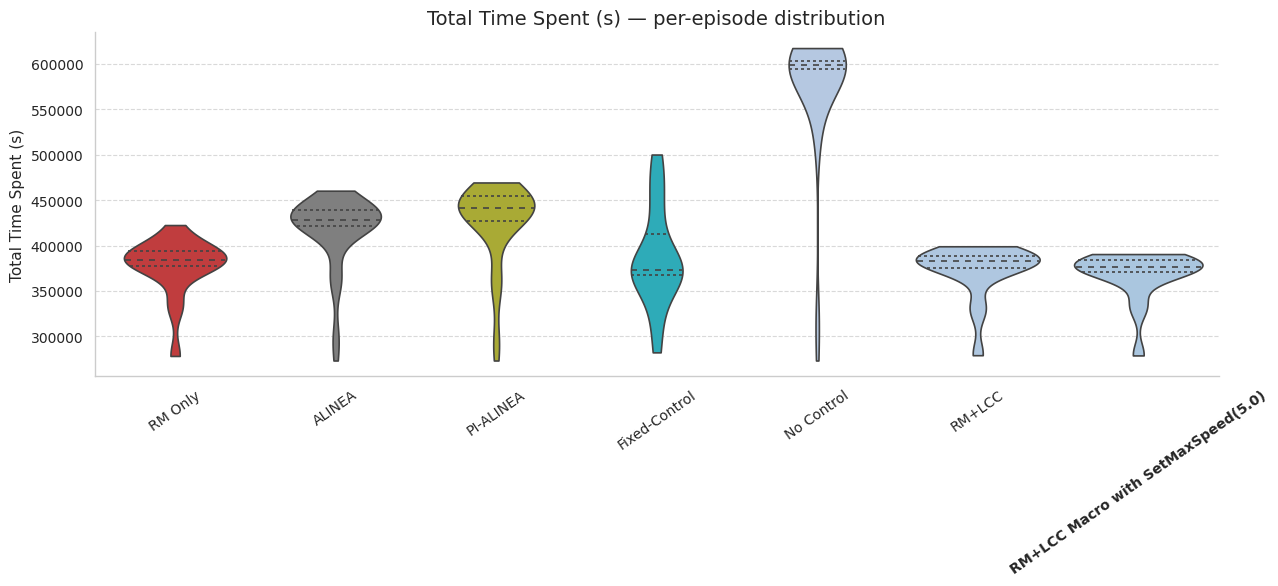

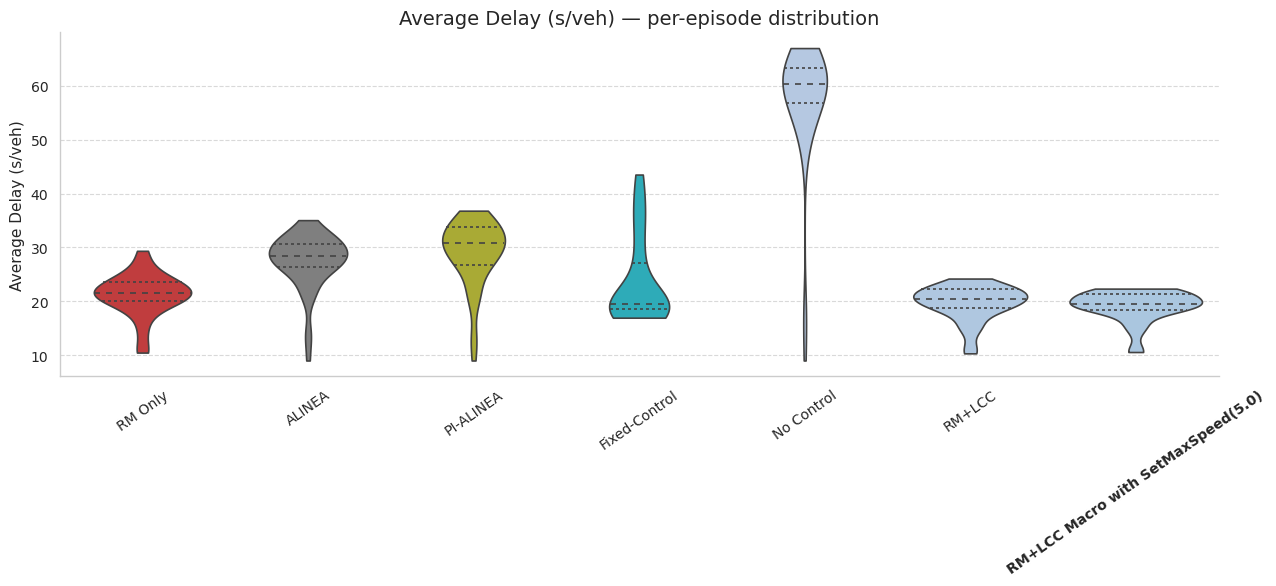

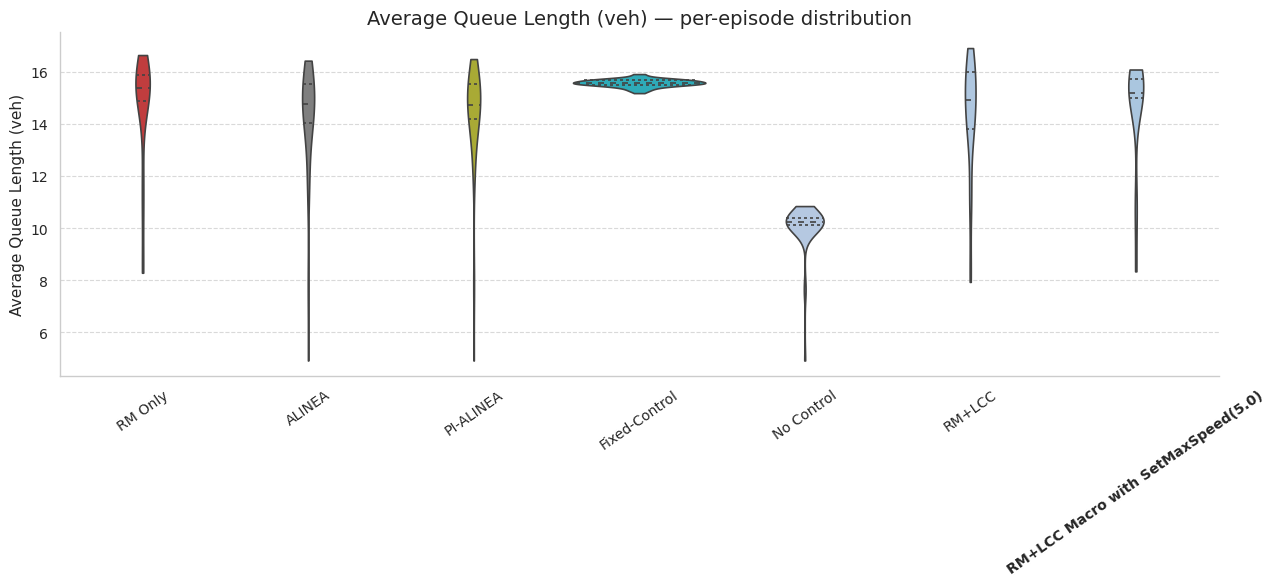

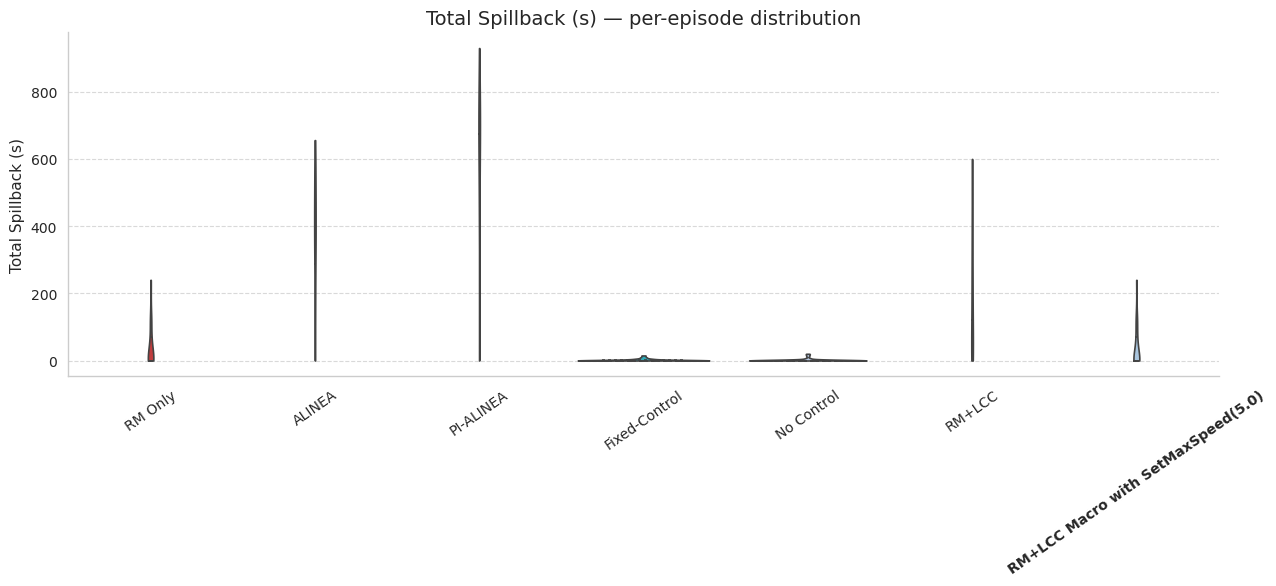

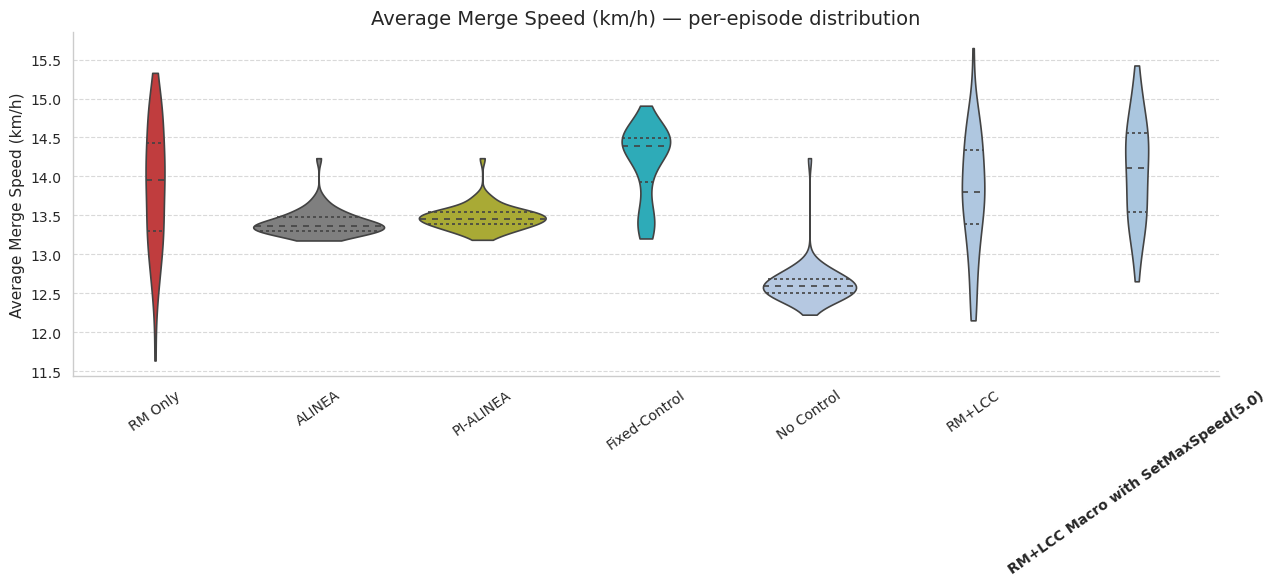

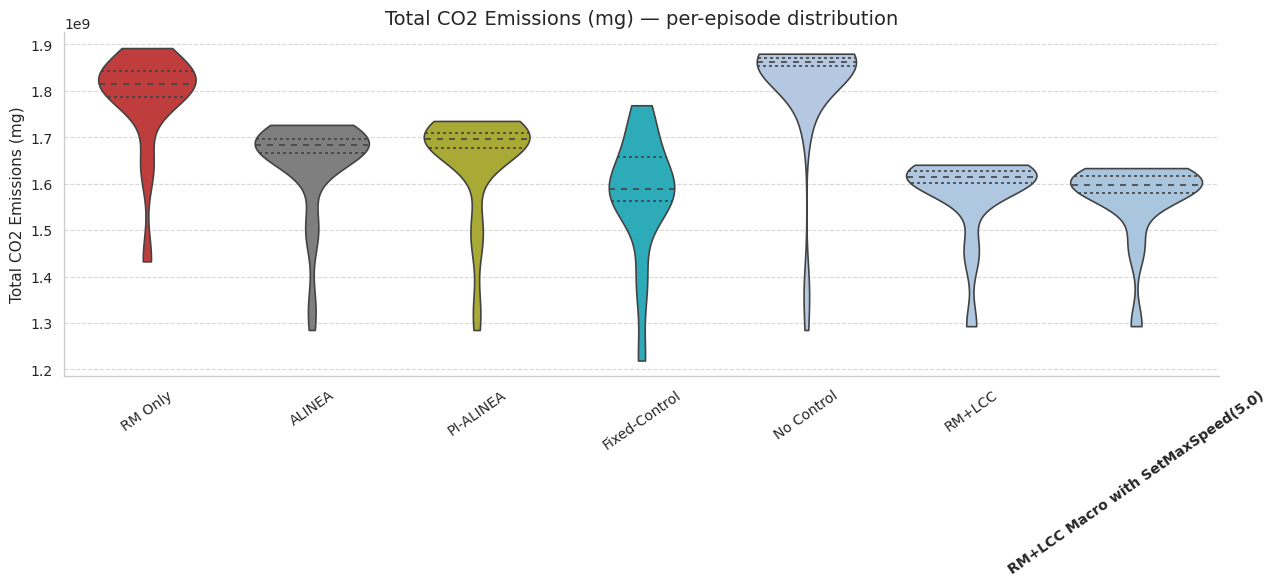

In [46]:
df_ordered = df.copy()
df_ordered["strategy"] = pd.Categorical(df_ordered["strategy"],
                                        categories=present_strategies, ordered=True)
palette = [STRATEGY_COLORS[s] for s in present_strategies]

for metric_key, metric_name in METRICS.items():
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.violinplot(data=df_ordered, x="strategy", y=metric_key,
                   palette=palette, inner="quartile", cut=0, ax=ax)
    title = f"{metric_name} — per-episode distribution"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name)
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        if label.get_text() == FOCUS_STRATEGY:
            label.set_fontweight("bold")
    save_fig(fig, "kpi_dashboard", title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## 4. Composite Score & Radar

Min-max normalize each KPI so that **1.0 = best** regardless of metric direction, then average the six normalized scores into a single composite. The radar chart compares the focus strategy against the top-3 composite performers and the bottom one — a quick visual signature.

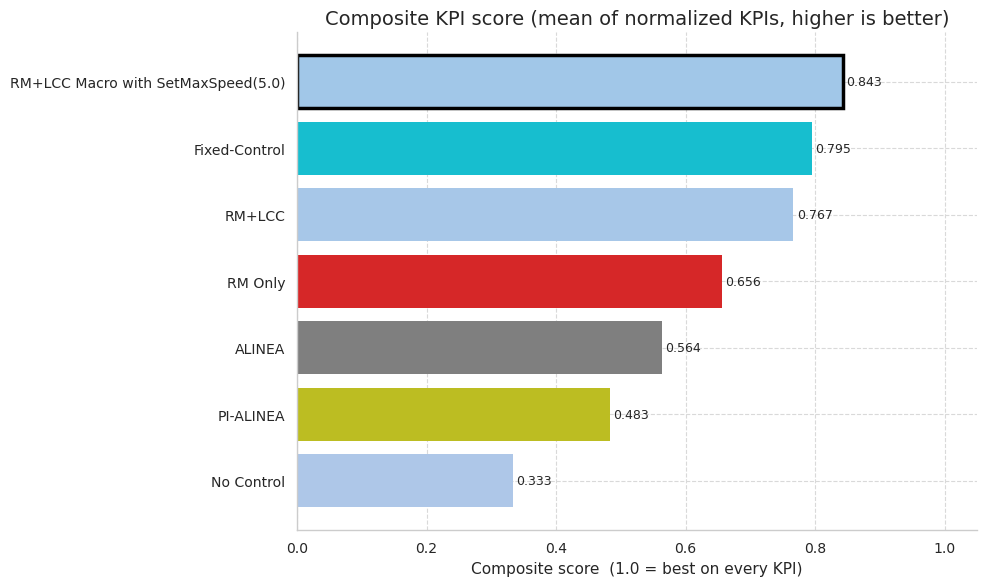

**Focus strategy ‹RM+LCC Macro with SetMaxSpeed(5.0)› composite rank: 1 / 7**

In [47]:
normalized = pd.DataFrame(
    {k: normalize_metric(strategy_means[k], k) for k in METRICS},
    index=strategy_means.index,
)
composite = normalized.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [STRATEGY_COLORS[s] for s in composite.index]
edges  = ["black" if s == FOCUS_STRATEGY else "none" for s in composite.index]
widths = [2.5     if s == FOCUS_STRATEGY else 0      for s in composite.index]
bars = ax.barh(composite.index, composite.values, color=colors,
               edgecolor=edges, linewidth=widths)
title = "Composite KPI score (mean of normalized KPIs, higher is better)"
ax.set_title(title, fontsize=14)
ax.set_xlabel("Composite score  (1.0 = best on every KPI)")
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
for bar, val in zip(bars, composite.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
save_fig(fig, "composite", title)
plt.tight_layout()
plt.show()
plt.close(fig)

display(Markdown(
    f"**Focus strategy ‹{FOCUS_STRATEGY}› composite rank: "
    f"{list(composite.index).index(FOCUS_STRATEGY) + 1} / {len(composite)}**"
))

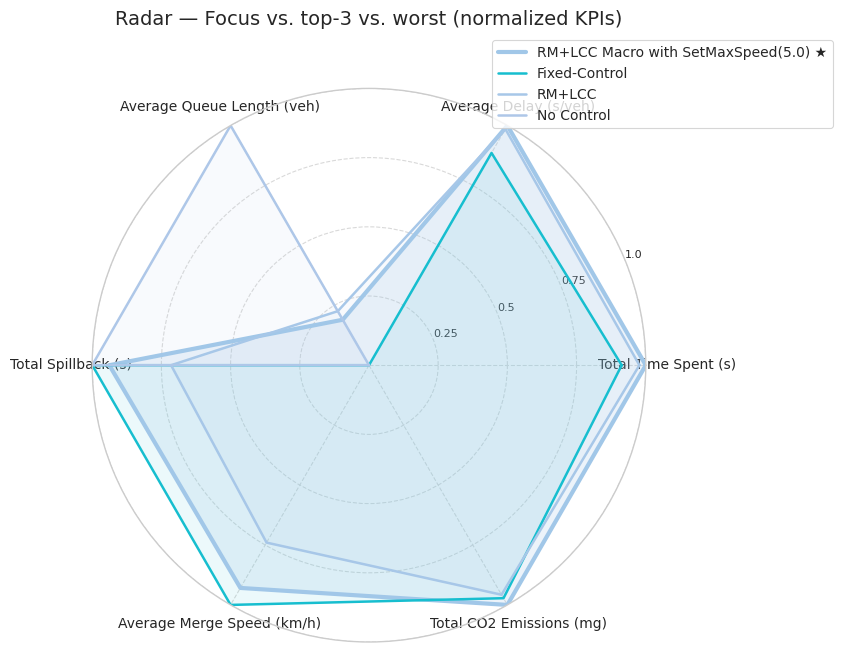

In [48]:
top3 = [s for s in composite.head(3).index]
worst = composite.tail(1).index[0]
radar_strategies = list(dict.fromkeys([FOCUS_STRATEGY, *top3, worst]))   # unique, ordered

labels  = [METRICS[k] for k in METRICS]
angles  = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for strat in radar_strategies:
    values = normalized.loc[strat].tolist()
    values += values[:1]
    is_focus = strat == FOCUS_STRATEGY
    ax.plot(angles, values, color=STRATEGY_COLORS[strat],
            linewidth=3 if is_focus else 1.8,
            label=strat + (" ★" if is_focus else ""))
    ax.fill(angles, values, color=STRATEGY_COLORS[strat],
            alpha=0.20 if is_focus else 0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=8)
ax.set_ylim(0, 1)
title = f"Radar — Focus vs. top-3 vs. worst (normalized KPIs)"
ax.set_title(title, y=1.10, fontsize=14)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10), fontsize=10)
save_fig(fig, "composite", title)
plt.tight_layout()
plt.show()
plt.close(fig)

## 5. Pairwise Improvement Matrix

For each KPI, every cell shows the percentage improvement of the **row** strategy over the **column** strategy. Green = row wins, red = row loses. Values are clipped at ±100 % for readability.

In [49]:
for metric_key, metric_name in METRICS.items():
    matrix = pd.DataFrame(index=present_strategies, columns=present_strategies, dtype=float)
    for r in present_strategies:
        for c in present_strategies:
            matrix.loc[r, c] = 0.0 if r == c else pct_improvement(
                strategy_means.loc[r, metric_key],
                strategy_means.loc[c, metric_key],
                metric_key,
            )
    display(Markdown(f"### Improvement matrix — {metric_name}"))
    display(
        matrix.style
        .background_gradient(cmap="RdYlGn", axis=None, vmin=-100, vmax=100)
        .format("{:+.1f}%")
        .set_caption("Row strategy vs. column strategy")
    )

### Improvement matrix — Total Time Spent (s)

,RM Only,ALINEA,PI-ALINEA,Fixed-Control,No Control,RM+LCC,RM+LCC Macro with SetMaxSpeed(5.0)
RM Only,+0.0%,+9.8%,+11.6%,+2.4%,+34.6%,-1.1%,-2.4%
ALINEA,-10.9%,+0.0%,+2.0%,-8.2%,+27.5%,-12.1%,-13.5%
PI-ALINEA,-13.2%,-2.1%,+0.0%,-10.4%,+26.0%,-14.4%,-15.8%
Fixed-Control,-2.5%,+7.6%,+9.4%,+0.0%,+33.0%,-3.6%,-4.9%
No Control,-52.9%,-37.9%,-35.1%,-49.2%,+0.0%,-54.5%,-56.5%
RM+LCC,+1.0%,+10.8%,+12.6%,+3.4%,+35.3%,+0.0%,-1.3%
RM+LCC Macro with SetMaxSpeed(5.0),+2.3%,+11.9%,+13.7%,+4.7%,+36.1%,+1.3%,+0.0%


### Improvement matrix — Average Delay (s/veh)

,RM Only,ALINEA,PI-ALINEA,Fixed-Control,No Control,RM+LCC,RM+LCC Macro with SetMaxSpeed(5.0)
RM Only,+0.0%,+23.0%,+27.2%,+9.9%,+63.0%,-7.5%,-10.6%
ALINEA,-29.9%,+0.0%,+5.4%,-17.0%,+51.9%,-39.6%,-43.6%
PI-ALINEA,-37.3%,-5.7%,+0.0%,-23.7%,+49.1%,-47.6%,-51.8%
Fixed-Control,-11.0%,+14.6%,+19.2%,+0.0%,+58.9%,-19.3%,-22.7%
No Control,-169.9%,-107.8%,-96.6%,-143.2%,+0.0%,-190.1%,-198.5%
RM+LCC,+6.9%,+28.4%,+32.2%,+16.2%,+65.5%,+0.0%,-2.9%
RM+LCC Macro with SetMaxSpeed(5.0),+9.6%,+30.4%,+34.1%,+18.5%,+66.5%,+2.8%,+0.0%


### Improvement matrix — Average Queue Length (veh)

...

,RM Only,ALINEA,PI-ALINEA,Fixed-Control,No Control,RM+LCC,RM+LCC Macro with SetMaxSpeed(5.0)
RM Only,+0.0%,+88.5%,+93.0%,-2684.8%,-3042.9%,+75.4%,-10.0%
ALINEA,-766.6%,+0.0%,+39.0%,-24032.9%,-27135.7%,-112.8%,-853.3%
PI-ALINEA,-1321.1%,-64.0%,+0.0%,-39474.7%,-44562.9%,-248.9%,-1463.2%
Fixed-Control,+96.4%,+99.6%,+99.7%,+0.0%,-12.9%,+99.1%,+96.0%
No Control,+96.8%,+99.6%,+99.8%,+11.4%,+0.0%,+99.2%,+96.5%
RM+LCC,-307.3%,+53.0%,+71.3%,-11241.8%,-12700.0%,+0.0%,-348.0%
RM+LCC Macro with SetMaxSpeed(5.0),+9.1%,+89.5%,+93.6%,-2431.6%,-2757.1%,+77.7%,+0.0%


### Improvement matrix — Average Merge Speed (km/h)

,RM Only,ALINEA,PI-ALINEA,Fixed-Control,No Control,RM+LCC,RM+LCC Macro with SetMaxSpeed(5.0)
RM Only,+0.0%,+3.3%,+2.8%,-2.3%,+9.7%,+0.6%,-1.6%
ALINEA,-3.2%,+0.0%,-0.5%,-5.5%,+6.2%,-2.7%,-4.7%
PI-ALINEA,-2.7%,+0.5%,+0.0%,-5.0%,+6.8%,-2.2%,-4.2%
Fixed-Control,+2.4%,+5.8%,+5.2%,+0.0%,+12.4%,+2.9%,+0.8%
No Control,-8.9%,-5.8%,-6.3%,-11.0%,+0.0%,-8.4%,-10.3%
RM+LCC,-0.5%,+2.8%,+2.2%,-2.9%,+9.1%,+0.0%,-2.1%
RM+LCC Macro with SetMaxSpeed(5.0),+1.6%,+5.0%,+4.4%,-0.8%,+11.5%,+2.1%,+0.0%


### Improvement matrix — Total CO2 Emissions (mg)

,RM Only,ALINEA,PI-ALINEA,Fixed-Control,No Control,RM+LCC,RM+LCC Macro with SetMaxSpeed(5.0)
RM Only,+0.0%,-8.3%,-7.7%,-13.1%,+2.1%,-12.9%,-13.6%
ALINEA,+7.7%,+0.0%,+0.6%,-4.4%,+9.6%,-4.2%,-4.9%
PI-ALINEA,+7.2%,-0.6%,+0.0%,-5.0%,+9.1%,-4.8%,-5.5%
Fixed-Control,+11.6%,+4.2%,+4.8%,+0.0%,+13.5%,+0.2%,-0.5%
No Control,-2.2%,-10.7%,-10.0%,-15.6%,+0.0%,-15.3%,-16.1%
RM+LCC,+11.4%,+4.0%,+4.6%,-0.2%,+13.3%,+0.0%,-0.7%
RM+LCC Macro with SetMaxSpeed(5.0),+12.0%,+4.7%,+5.2%,+0.4%,+13.9%,+0.7%,+0.0%


## 6. Demand-Conditioned KPI Heatmaps

For each KPI, a strategy × demand-cell heatmap. Each column is one of the nine demand conditions (`mainline / on-ramp`), gradient is column-wise so colours rank strategies within that demand.

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


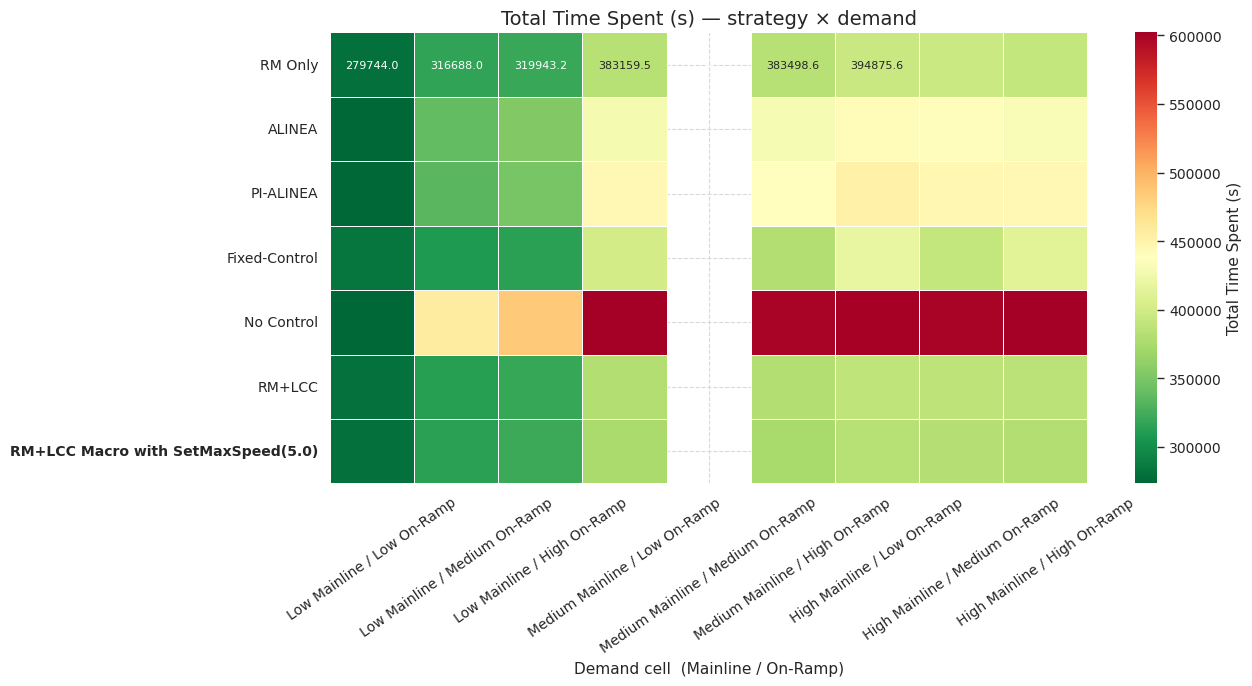

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


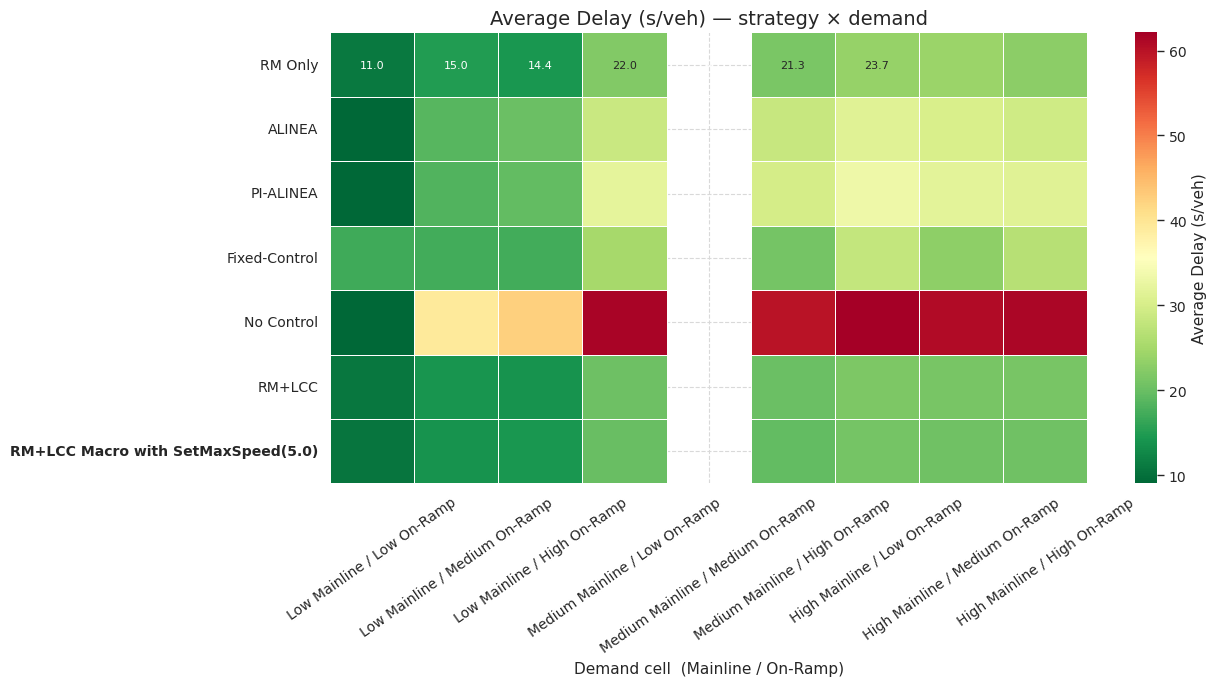

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


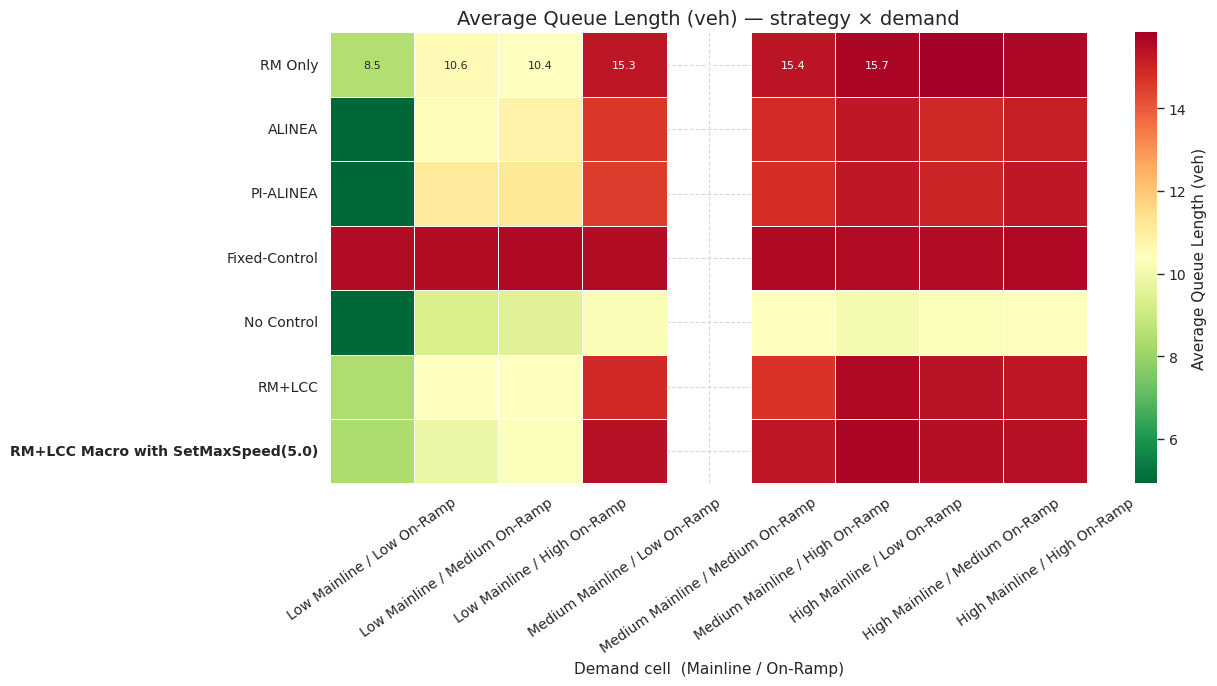

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


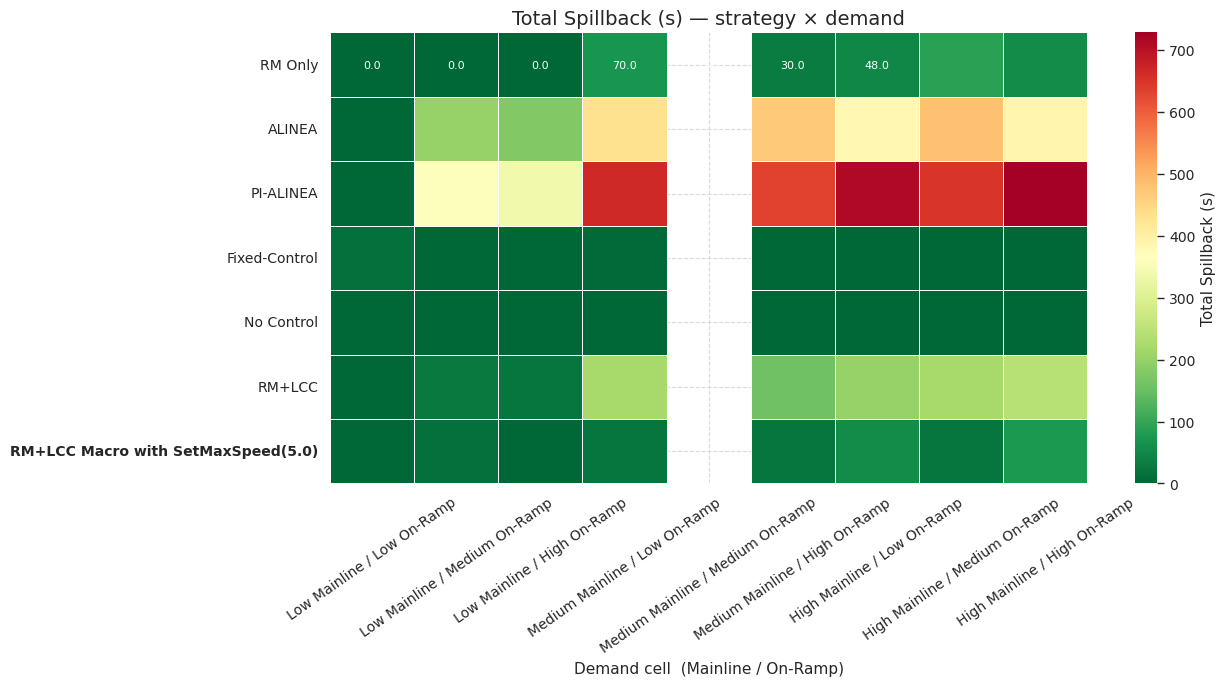

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


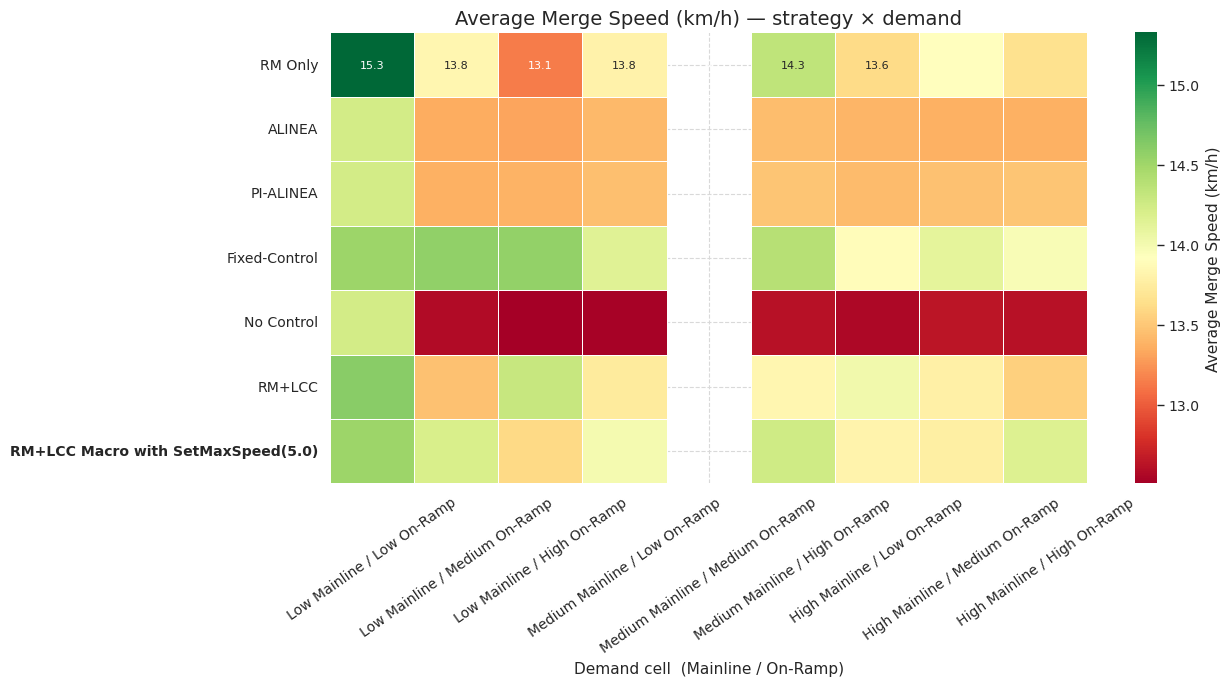

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


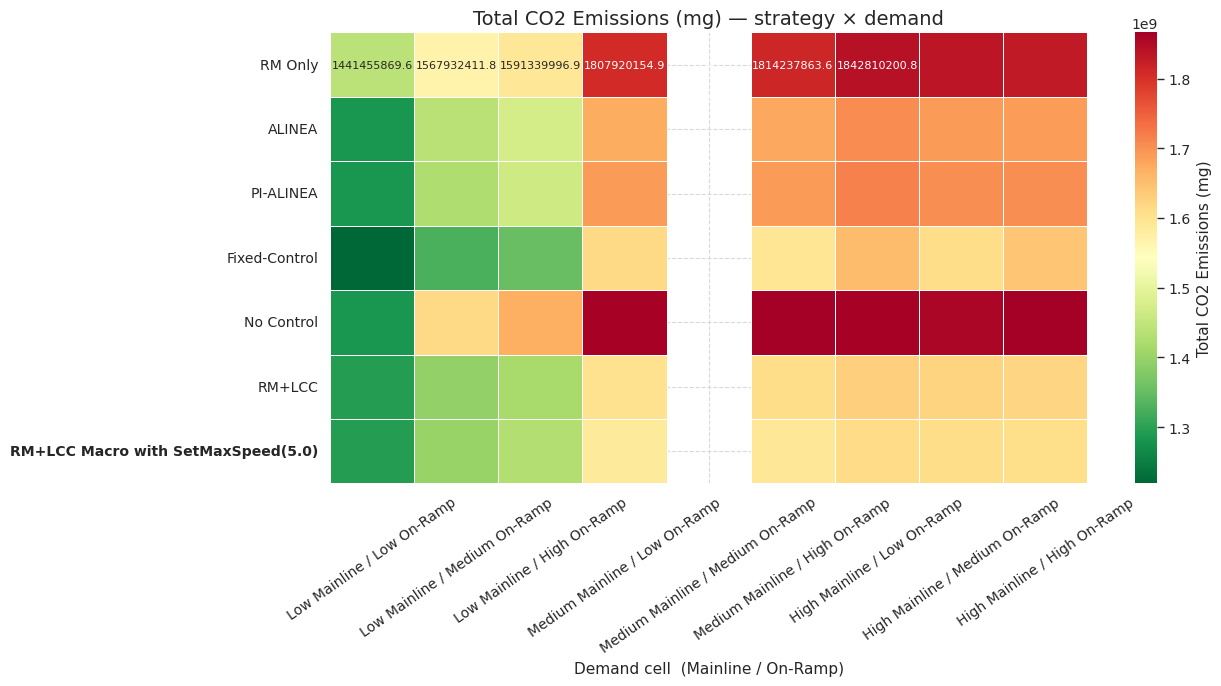

In [50]:
demand_cells = [f"{m} / {r}" for m in MAINLINE_LEVELS for r in RAMP_LEVELS]

for metric_key, metric_name in METRICS.items():
    pivot = (
        df.groupby(["strategy", "demand_cell"], observed=True)[metric_key]
        .mean()
        .unstack("demand_cell")
        .reindex(index=present_strategies, columns=demand_cells)
    )

    fig, ax = plt.subplots(figsize=(13, 7))
    cmap = "RdYlGn" if metric_key in HIGHER_IS_BETTER else "RdYlGn_r"
    sns.heatmap(pivot, cmap=cmap, annot=True, fmt=".1f",
                annot_kws={"size": 8}, linewidths=0.4, linecolor="white",
                cbar_kws={"label": metric_name}, ax=ax)
    title = f"{metric_name} — strategy × demand"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Demand cell  (Mainline / On-Ramp)")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_yticklabels():
        if label.get_text() == FOCUS_STRATEGY:
            label.set_fontweight("bold")
    save_fig(fig, "demand_heatmaps", title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## 7. Focus Strategy Deep Dive

Everything in this section is computed for **`FOCUS_STRATEGY`**. Change the constant at the top of the notebook and rerun this section to compare any other strategy.

In [51]:
focus_rank = list(composite.index).index(FOCUS_STRATEGY) + 1
display(Markdown(
    f"### Focus strategy: **{FOCUS_STRATEGY}**\n\n"
    f"Composite rank: **{focus_rank} of {len(composite)}** &nbsp;&nbsp;|&nbsp;&nbsp; "
    f"Composite score: **{composite[FOCUS_STRATEGY]:.3f}**"
))

### Focus strategy: **RM+LCC Macro with SetMaxSpeed(5.0)**

Composite rank: **1 of 7** &nbsp;&nbsp;|&nbsp;&nbsp; Composite score: **0.843**

In [52]:
others = [s for s in present_strategies if s != FOCUS_STRATEGY]
rows = []
for other in others:
    row = {"Compared against": other}
    for metric_key, metric_name in METRICS.items():
        row[metric_name] = pct_improvement(
            strategy_means.loc[FOCUS_STRATEGY, metric_key],
            strategy_means.loc[other, metric_key],
            metric_key,
        )
    rows.append(row)
improvement_df = pd.DataFrame(rows).set_index("Compared against")

display(Markdown(f"**% Improvement of {FOCUS_STRATEGY} vs. each other strategy**"))
display(
    improvement_df.style
    .format("{:+.2f}%")
    .background_gradient(cmap="RdYlGn", axis=None, vmin=-50, vmax=50)
)

**% Improvement of RM+LCC Macro with SetMaxSpeed(5.0) vs. each other strategy**

,Total Time Spent (s),Average Delay (s/veh),Average Queue Length (veh),Total Spillback (s),Average Merge Speed (km/h),Total CO2 Emissions (mg)
Compared against,,,,,,
RM Only,+2.32%,+9.56%,+1.10%,+9.09%,+1.58%,+11.99%
ALINEA,+11.91%,+30.38%,-2.48%,+89.51%,+4.96%,+4.66%
PI-ALINEA,+13.68%,+34.14%,-1.74%,+93.60%,+4.42%,+5.20%
Fixed-Control,+4.68%,+18.51%,+6.71%,-2431.65%,-0.78%,+0.45%
No Control,+36.10%,+66.50%,-44.38%,-2757.14%,+11.48%,+13.85%
RM+LCC,+1.28%,+2.81%,-1.37%,+77.68%,+2.14%,+0.68%


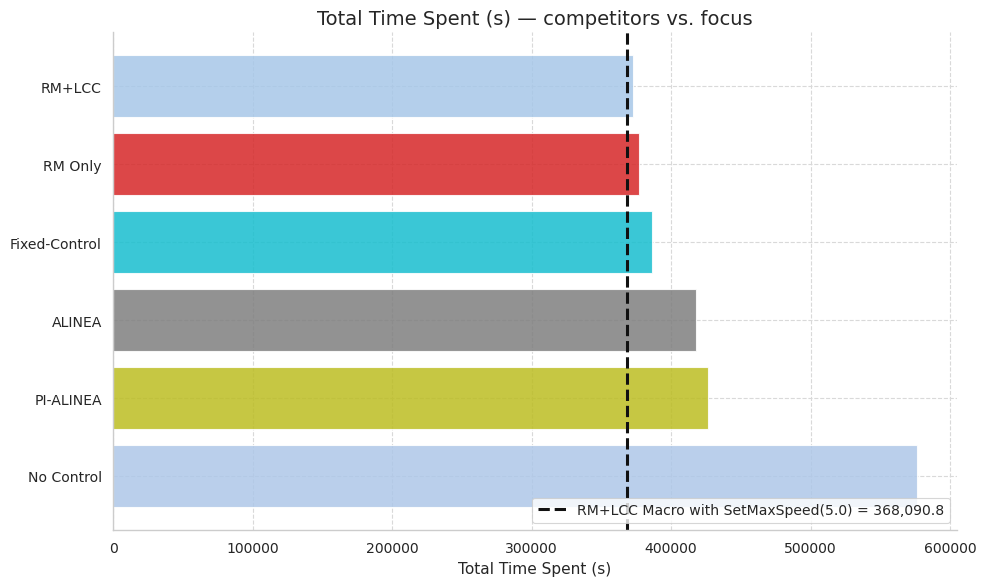

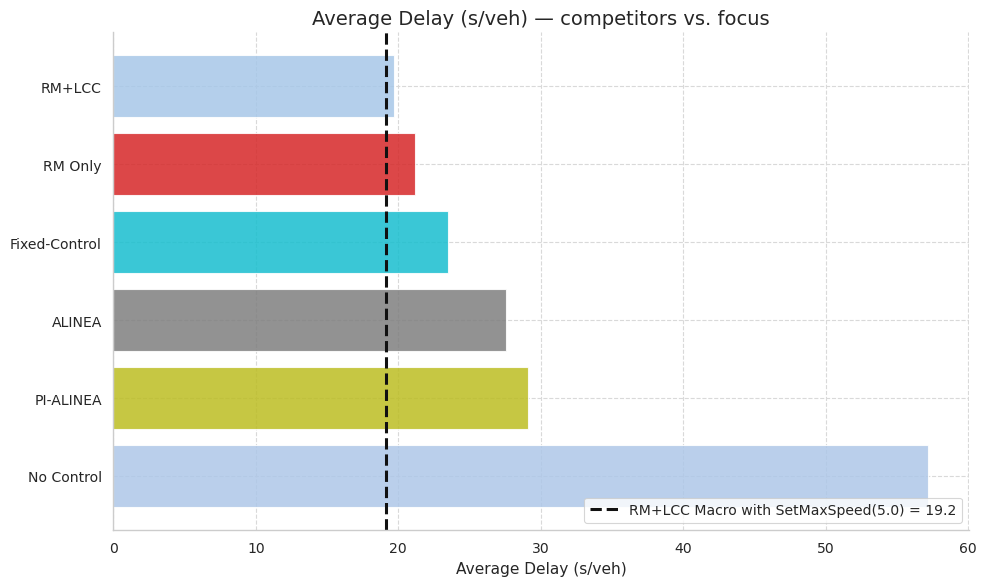

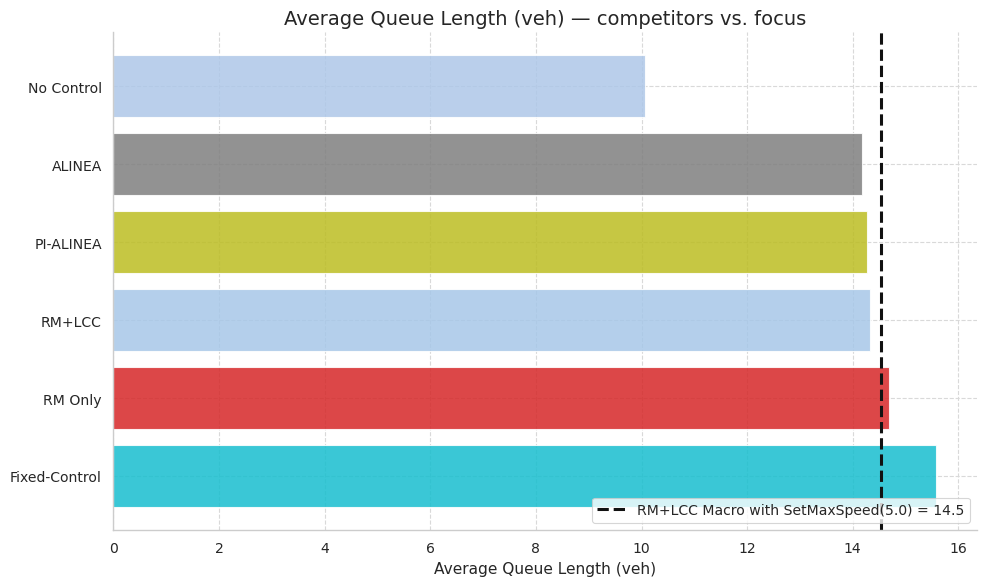

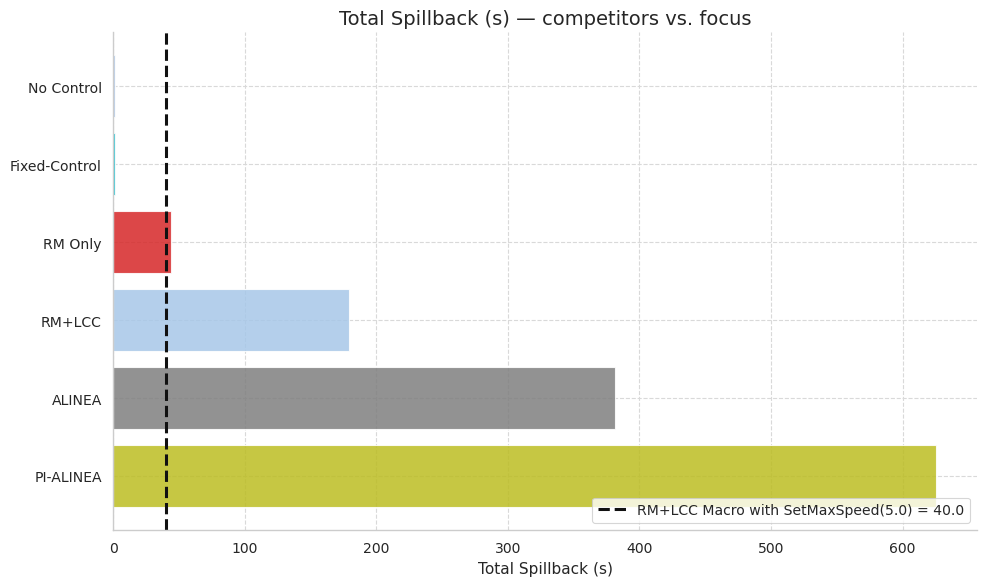

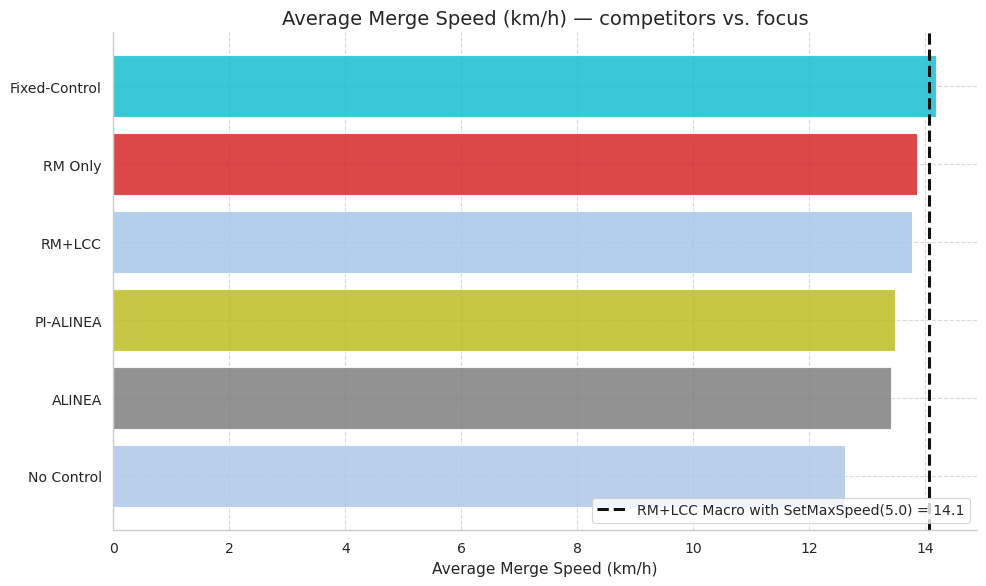

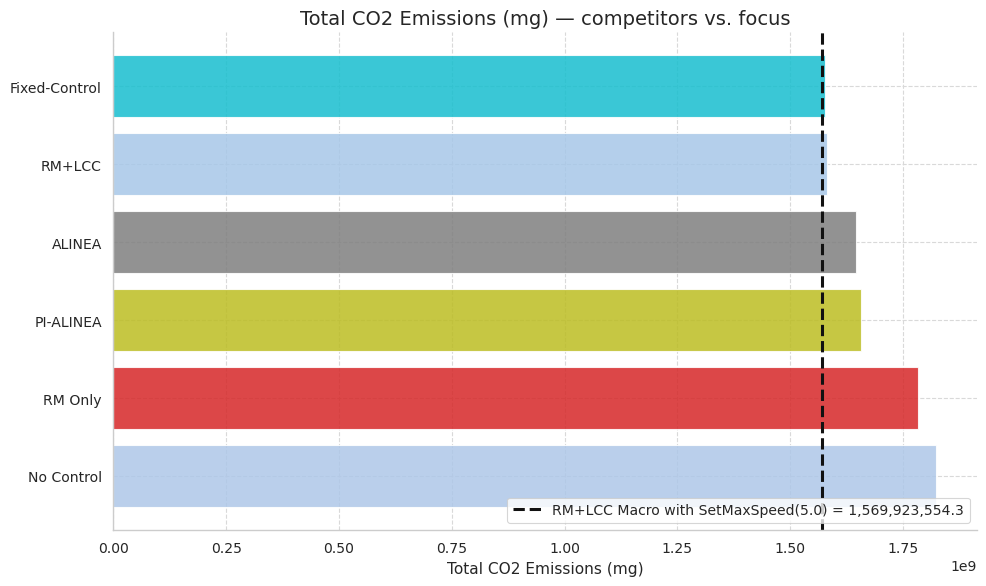

In [53]:
for metric_key, metric_name in METRICS.items():
    series = strategy_means[metric_key].drop(FOCUS_STRATEGY)
    series = series.sort_values(ascending=metric_sort_ascending(metric_key))
    focus_val = strategy_means.loc[FOCUS_STRATEGY, metric_key]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [STRATEGY_COLORS[s] for s in series.index]
    ax.barh(series.index, series.values, color=colors, alpha=0.85)
    ax.axvline(focus_val, color=FOCUS_COLOR, linestyle="--", linewidth=2.2,
               label=f"{FOCUS_STRATEGY} = {focus_val:,.1f}")
    title = f"{metric_name} — competitors vs. focus"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(metric_name)
    ax.invert_yaxis()
    ax.legend(loc="lower right")
    save_fig(fig, "focus", title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

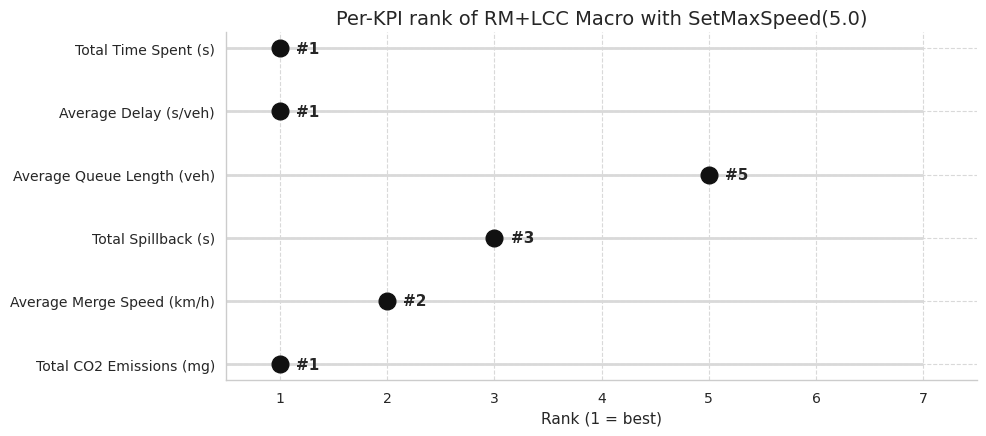

In [54]:
ranks = {}
for metric_key in METRICS:
    ordered = strategy_means[metric_key].sort_values(
        ascending=metric_sort_ascending(metric_key)
    ).index.tolist()
    ranks[METRICS[metric_key]] = ordered.index(FOCUS_STRATEGY) + 1

rank_df = pd.Series(ranks, name="Rank").to_frame()
rank_df["Out of"] = len(present_strategies)

fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(rank_df))
ax.hlines(y, 0, len(present_strategies), color="0.85", linewidth=2)
ax.plot(rank_df["Rank"], y, "o", color=FOCUS_COLOR, markersize=12)
for i, (metric_name, row) in enumerate(rank_df.iterrows()):
    ax.text(row["Rank"] + 0.15, i, f"#{row['Rank']}", va="center", fontsize=11, fontweight="bold")
ax.set_yticks(y, labels=rank_df.index)
ax.set_xticks(range(1, len(present_strategies) + 1))
ax.set_xlim(0.5, len(present_strategies) + 0.5)
ax.invert_yaxis()
title = f"Per-KPI rank of {FOCUS_STRATEGY}"
ax.set_title(title, fontsize=14)
ax.set_xlabel("Rank (1 = best)")
ax.grid(axis="x", linestyle="--", color="0.85")
save_fig(fig, "focus", title)
plt.tight_layout()
plt.show()
plt.close(fig)

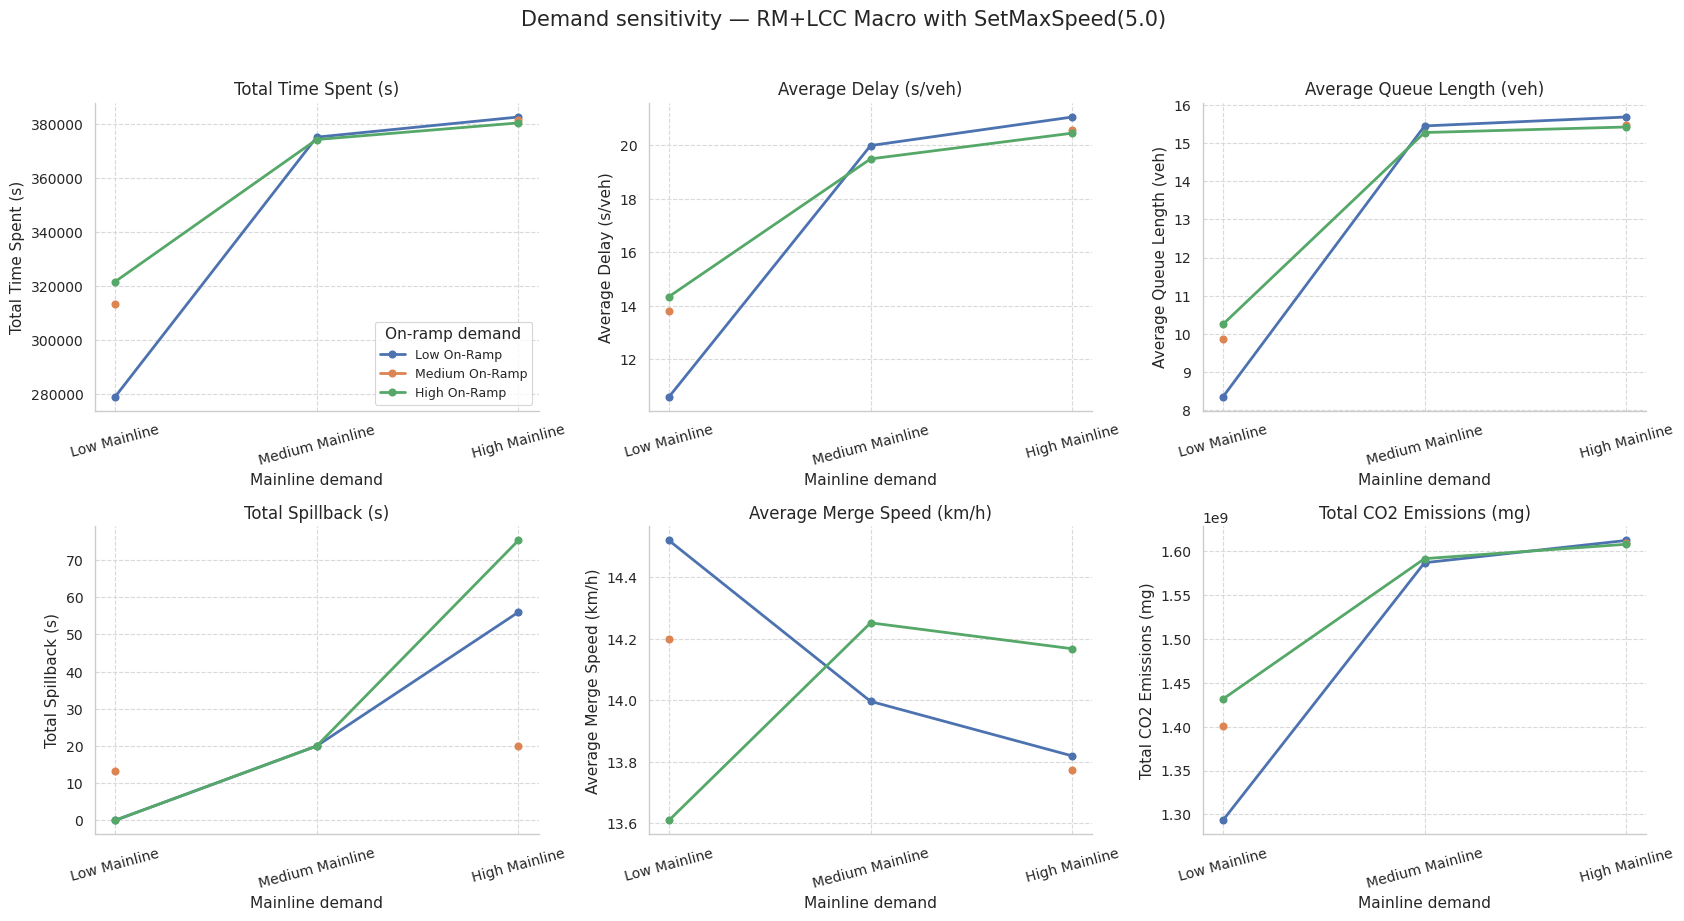

In [55]:
focus_df = df[df["strategy"] == FOCUS_STRATEGY]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (metric_key, metric_name) in zip(axes.ravel(), METRICS.items()):
    grouped = (
        focus_df.groupby(["mainline_demand", "on_ramp_demand"], observed=True)[metric_key]
        .mean().unstack("on_ramp_demand").reindex(index=MAINLINE_LEVELS, columns=RAMP_LEVELS)
    )
    for ramp_lvl in RAMP_LEVELS:
        ax.plot(MAINLINE_LEVELS, grouped[ramp_lvl], marker="o",
                linewidth=2, label=ramp_lvl)
    ax.set_title(metric_name, fontsize=12)
    ax.set_xlabel("Mainline demand")
    ax.set_ylabel(metric_name)
    ax.tick_params(axis="x", rotation=15)

axes[0, 0].legend(title="On-ramp demand", loc="best", fontsize=9)
title = f"Demand sensitivity — {FOCUS_STRATEGY}"
fig.suptitle(title, fontsize=15, y=1.02)
save_fig(fig, "focus", title)
plt.tight_layout()
plt.show()
plt.close(fig)

In [56]:
display(Markdown(f"**Best 5 and worst 5 episodes of {FOCUS_STRATEGY} (ranked by composite per-episode)**"))

episode_norm = pd.DataFrame(
    {k: normalize_metric(focus_df[k], k) for k in METRICS},
    index=focus_df.index,
)
focus_with_score = focus_df.assign(_score=episode_norm.mean(axis=1))
show_cols = ["episode_id", "main_flow_vph", "on_ramp_flow_vph", *METRICS.keys(), "_score"]

best5  = focus_with_score.nlargest(5,  "_score")[show_cols].rename(columns={"_score": "composite"})
worst5 = focus_with_score.nsmallest(5, "_score")[show_cols].rename(columns={"_score": "composite"})

display(Markdown("**Top 5 episodes**"))
display(best5.style.format({c: "{:,.2f}" for c in best5.columns if c != "episode_id"}))
display(Markdown("**Bottom 5 episodes**"))
display(worst5.style.format({c: "{:,.2f}" for c in worst5.columns if c != "episode_id"}))

**Best 5 and worst 5 episodes of RM+LCC Macro with SetMaxSpeed(5.0) (ranked by composite per-episode)**

**Top 5 episodes**

,episode_id,main_flow_vph,on_ramp_flow_vph,total_travel_time,avg_time_loss,avg_ramp_queue_veh,total_spillback_time_sec,avg_mainline_speed_mergeArea_km/h,total_co2_mg,composite
304,4,"4,000.00","1,500.00","279,079.00",10.60,8.35,0.00,14.52,"1,293,229,166.59",0.95
305,5,"4,000.00","1,600.00","280,378.00",10.81,8.34,0.00,14.59,"1,299,166,984.28",0.94
301,1,"4,000.00","1,800.00","280,301.00",10.72,8.35,0.00,14.08,"1,299,663,415.89",0.91
329,29,"4,500.00","1,700.00","327,435.00",15.40,10.37,0.00,13.78,"1,447,138,126.65",0.64
331,31,"4,500.00","1,700.00","332,625.00",15.24,10.87,40.00,14.23,"1,456,859,089.35",0.62


**Bottom 5 episodes**

,episode_id,main_flow_vph,on_ramp_flow_vph,total_travel_time,avg_time_loss,avg_ramp_queue_veh,total_spillback_time_sec,avg_mainline_speed_mergeArea_km/h,total_co2_mg,composite
306,6,"6,500.00","2,000.00","385,219.00",21.96,15.71,240.00,13.61,"1,612,602,114.88",0.09
344,44,"6,000.00","1,900.00","389,172.00",22.13,15.76,120.00,12.65,"1,623,030,913.54",0.10
336,36,"6,000.00","1,900.00","384,433.00",21.55,15.75,240.00,14.26,"1,618,429,331.12",0.13
341,41,"6,000.00","1,500.00","389,378.00",22.36,15.99,160.00,13.92,"1,629,960,259.04",0.14
333,33,"6,500.00","1,900.00","388,147.00",21.83,16.06,120.00,13.47,"1,630,165,272.84",0.15


## 8. Robustness & Trade-offs

- **Coefficient of variation** (std / mean) per strategy per KPI — lower means the strategy behaves more consistently across the 50 episodes.
- **Trade-off scatter plots** between metric pairs that capture two important tensions: mainline vs ramp fairness, and efficiency vs emissions. Dots are per-strategy means; the focus strategy is highlighted.

In [57]:
stds  = df.groupby("strategy", sort=False)[list(METRICS)].std().reindex(present_strategies)
means = strategy_means
cov = (stds / means.abs()).rename(columns=METRICS)

display(Markdown("**Coefficient of variation per strategy (lower = more consistent)**"))
display(
    cov.style
    .format("{:.3f}")
    .background_gradient(cmap="RdYlGn_r", axis=0)
)

**Coefficient of variation per strategy (lower = more consistent)**

,Total Time Spent (s),Average Delay (s/veh),Average Queue Length (veh),Total Spillback (s),Average Merge Speed (km/h),Total CO2 Emissions (mg)
strategy,,,,,,
RM Only,0.085,0.189,0.145,1.472,0.058,0.061
ALINEA,0.095,0.184,0.159,0.445,0.013,0.062
PI-ALINEA,0.106,0.208,0.152,0.319,0.012,0.066
Fixed-Control,0.140,0.338,0.009,2.050,0.034,0.083
No Control,0.127,0.205,0.092,2.982,0.022,0.070
RM+LCC,0.079,0.164,0.151,0.946,0.055,0.057
RM+LCC Macro with SetMaxSpeed(5.0),0.074,0.150,0.148,1.539,0.047,0.053


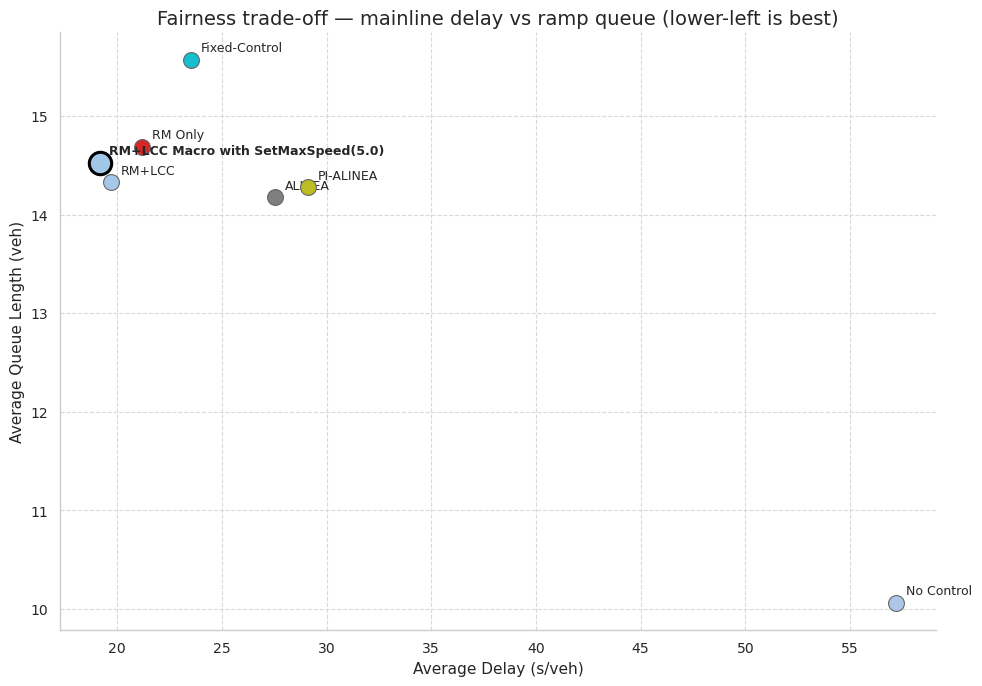

In [58]:
def trade_off_plot(x_key: str, y_key: str, title: str, section: str = "tradeoffs"):
    fig, ax = plt.subplots(figsize=(10, 7))
    for strat in present_strategies:
        x = strategy_means.loc[strat, x_key]
        y = strategy_means.loc[strat, y_key]
        is_focus = strat == FOCUS_STRATEGY
        ax.scatter(x, y, s=260 if is_focus else 130,
                   color=STRATEGY_COLORS[strat],
                   edgecolor="black" if is_focus else "0.4",
                   linewidth=2.2 if is_focus else 0.8, zorder=3)
        ax.annotate(strat, (x, y),
                    xytext=(7, 6), textcoords="offset points",
                    fontsize=9, fontweight="bold" if is_focus else "normal")
    ax.set_xlabel(METRICS[x_key])
    ax.set_ylabel(METRICS[y_key])
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle="--", color="0.85")
    save_fig(fig, section, title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

trade_off_plot(
    "avg_time_loss", "avg_ramp_queue_veh",
    "Fairness trade-off — mainline delay vs ramp queue (lower-left is best)",
)

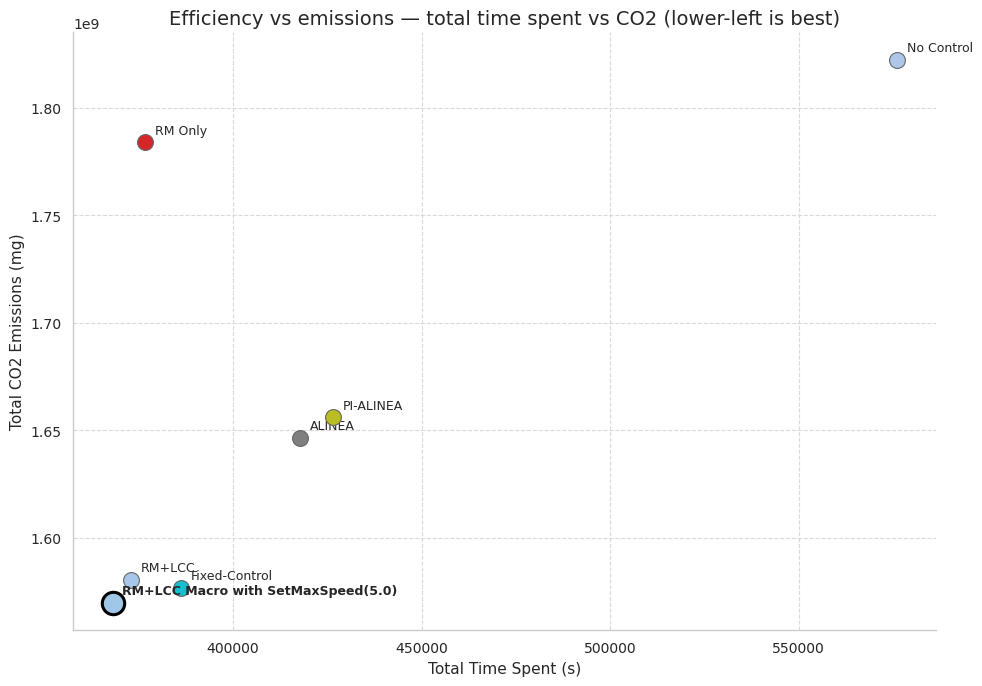

In [59]:
trade_off_plot(
    "total_travel_time", "total_co2_mg",
    "Efficiency vs emissions — total time spent vs CO2 (lower-left is best)",
)

## Wrap-up

- **To deep-dive a different strategy:** set `FOCUS_STRATEGY` at the top to any name from `STRATEGY_CATALOG` and re-run Sections 4–7.
- **All figures** are saved to `plots/analysis/<section>/<figure>.png`.
- **Composite score** is a min-max average across the six KPIs (no statistical weighting). Treat the ranking as a visual heuristic, not a formal optimum.